In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf 

In [9]:
abs_data = pd.read_csv("/Users/waqarmohiuddin/Downloads/Untitled 6.csv")

abs_data

abs_data.iloc[:, 1:] = abs_data.iloc[:, 1:].replace(',', '', regex=True).astype(int)

# Convert from wide to long format
df_long = abs_data.melt(id_vars=abs_data.columns[0], var_name="Year", value_name="Count")

In [10]:
df_long

,Principal offence(b)(c),Year,Count
0,01 Homicide and related offences(e),2008–09,816
1,011 Murder,2008–09,318
2,012 Attempted Murder,2008–09,232
3,013 Manslaughter and driving causing death,2008–09,260
4,02 Acts intended to cause injury(f),2008–09,72069
...,...,...,...
587,133 Offensive conduct,2023-24,4664
588,15 Offences against justice(n)(o),2023-24,31101
589,153 Breach of violence and non-violence orders,2023-24,20073
590,156 Offences against justice procedures,2023-24,7620


In [19]:
import matplotlib.ticker as mtick

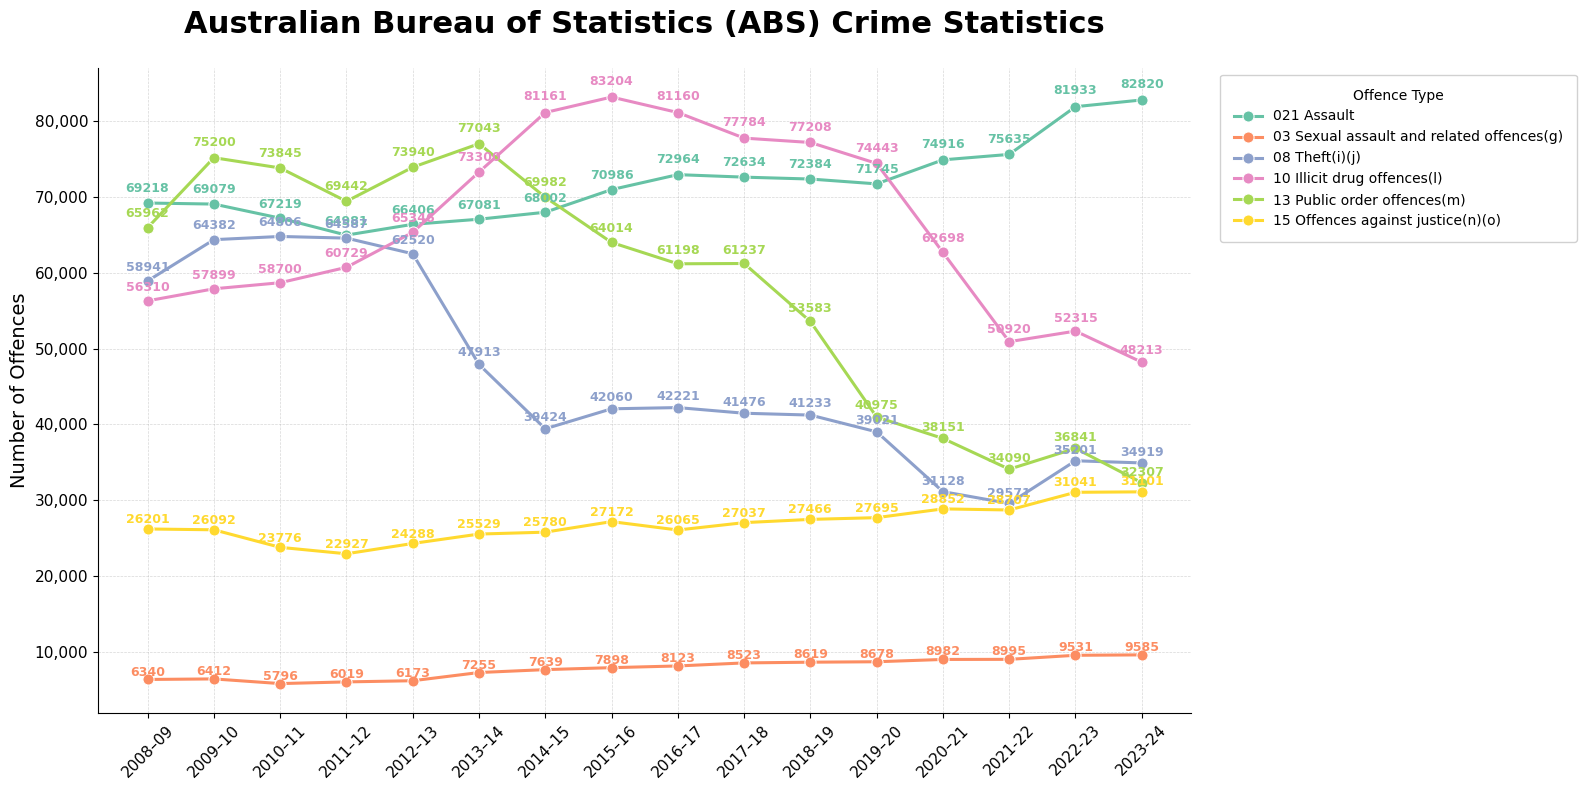

In [21]:
measures = [ "02 Acts intended to cause injury(f)", "03 Sexual assault and related offences(g)", "13 Public order offences(m)", "08 Theft(i)(j)", "021 Assault", "10 Illicit drug offences(l)", "15 Offences against justice(n)(o)"]

plt.figure(figsize=(16, 8))
ax = sns.lineplot(
    data= df_long[df_long['Principal offence(b)(c) '].isin(measures)],
    x="Year", y="Count",
    hue='Principal offence(b)(c) ',
    marker="o",
    linewidth=2.2,
    markersize=8,
    palette="Set2"
)

# Add numbers to markers (offset so they don't touch the point)
for line in ax.lines:
    y = line.get_ydata()
    x = line.get_xdata()

    for xi, yi in zip(x, y):
        ax.text(
            xi,
            yi + (yi * 0.015),  # slight vertical offset (1.5%)
            f"{int(yi)}",
            fontsize=9,
            ha="center",
            va="bottom",
            color=line.get_color(),
            fontweight="semibold"
        )

# Title + labels
plt.title(
    "Australian Bureau of Statistics (ABS) Crime Statistics",
    fontsize=22,
    pad=25,
    fontweight="bold"
)

plt.xlabel("")
plt.ylabel("Number of Offences", fontsize=14)

plt.xticks(rotation=45, fontsize=11)
plt.yticks(fontsize=11)

# Soft grid
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)

# Legend moved outside right
plt.legend(
    title="Offence Type",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=True,
    framealpha=0.9,
    borderpad=1
)
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))  # adds commas
sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()

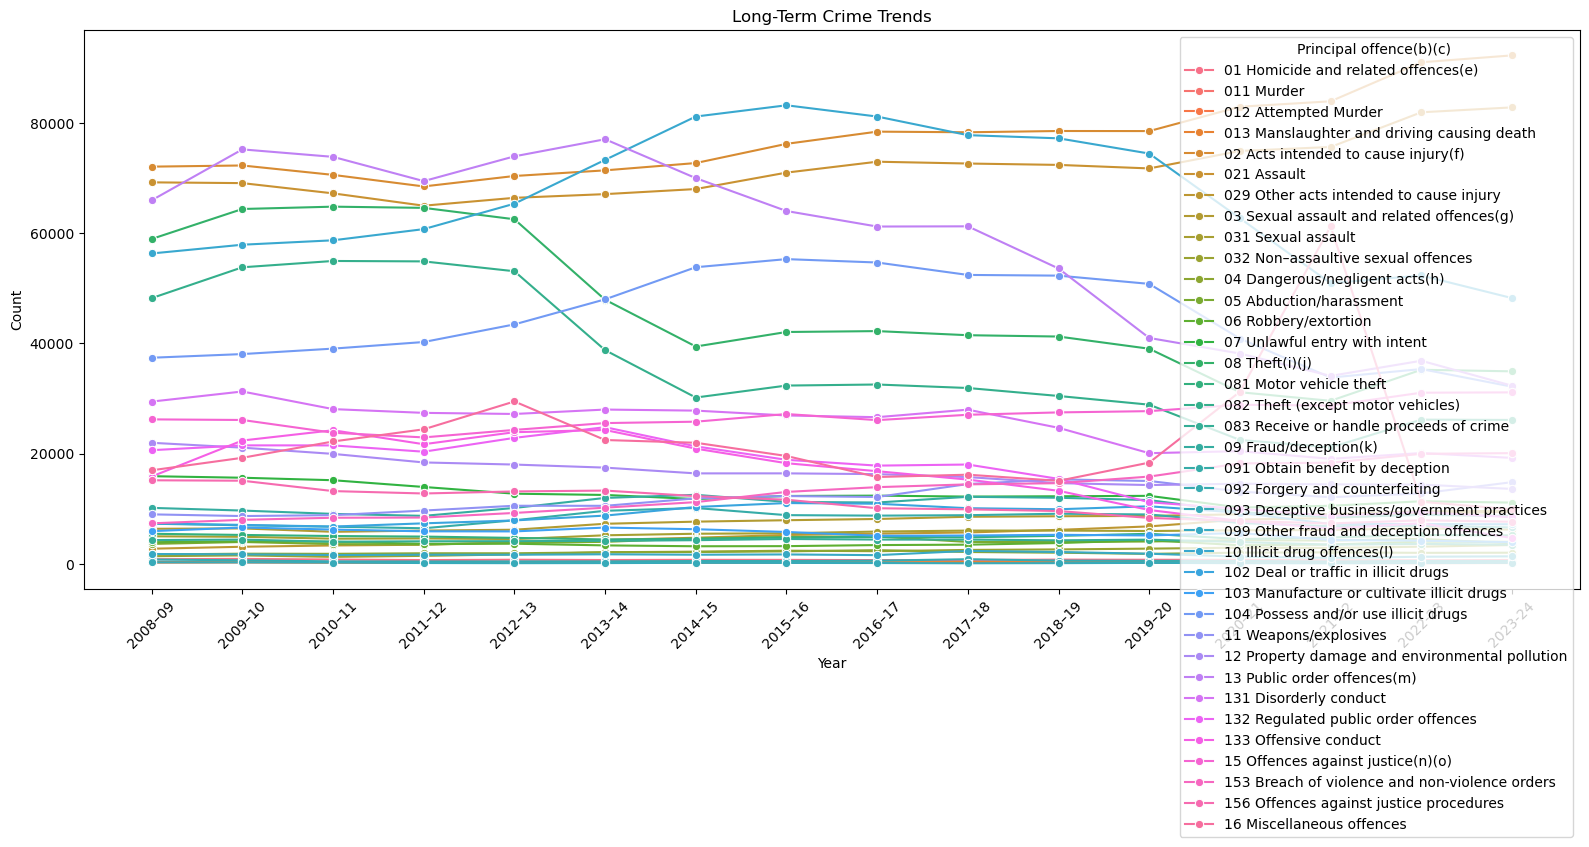

In [15]:
plt.figure(figsize=(16,8))
sns.lineplot(data=df_long, x="Year", y="Count", hue=df_long.columns[0], marker="o")
plt.xticks(rotation=45)
plt.title("Long-Term Crime Trends")
plt.tight_layout()
plt.show()

In [16]:
print(df_long.columns)

Index(['Principal offence(b)(c) ', 'Year', 'Count'], dtype='object')
